In [1]:
pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 7.2 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [5]:
import xgboost as xgb
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

#load titanic dataset
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].dropna()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

X = df.drop('survived', axis = 1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)
print("Data Ready", X_train.shape)

Data Ready (569, 5)


In [10]:
from sklearn.ensemble import RandomForestClassifier

#train xgboost model
xgb_model = xgb.XGBClassifier(
    n_estimators = 100,
    max_depth = 4,
    learning_rate = 0.1,
    random_state = 42,
    eval_metrics = 'logloss'
)
xgb_model.fit(X_train, y_train)

#train random forest model
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 4,
    random_state = 42
)
rf_model.fit(X_train, y_train)

#model comparison
print("XGBoost")
print(f" Train {xgb_model.score(X_train, y_train)}")
print(f" Test {xgb_model.score(X_test, y_test)}")

print("Random Forest")
print(f" Train {rf_model.score(X_train, y_train)}")
print(f" Test {rf_model.score(X_test, y_test)}")

XGBoost
 Train 0.9209138840070299
 Test 0.8111888111888111
Random Forest
 Train 0.843585237258348
 Test 0.8041958041958042


/opt/homebrew/Cellar/jupyterlab/4.5.1/libexec/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [18:53:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


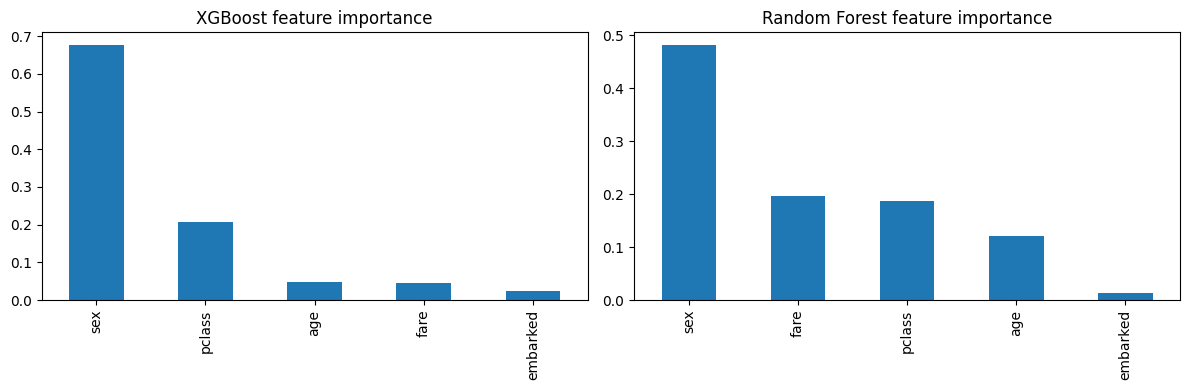

In [13]:
import matplotlib.pyplot as plt

#XGB feature importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index = X.columns
).sort_values(ascending=False)

#Random forest feature importance
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index = X.columns
).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4))

xgb_importance.plot(kind='bar', ax = ax1, title = 'XGBoost feature importance')
rf_importance.plot(kind= 'bar', ax= ax2, title = 'Random Forest feature importance')
plt.tight_layout()
plt.show()

In [19]:
#tuning XGBoost 
#more conservative setting

xgb_tuned = xgb.XGBClassifier(
    n_estimators = 200,
    max_depth = 3,
    learning_rate = 0.05,
    subsample = 0.8, #use 80% of data per tree
    colsample_bytree=0.8, #use 80% of features per tree
    random_state = 42,
    eval_metric = 'logloss'
)
xgb_tuned.fit(X_train, y_train)
print("Tuned XGBoost")
print(f" Train {xgb_tuned.score(X_train, y_train)}")
print(f" Test {xgb_tuned.score(X_test, y_test)}")

    

Tuned XGBoost
 Train 0.8945518453427065
 Test 0.8181818181818182


NameError: name 'pipe' is not defined